# Tutorial 5: MERFISH Mouse Inflamed Colons

In this tutorial, we applied NovAST to mouse MERFISH colon samples in the [study](https://www.cell.com/cell/fulltext/S0092-8674(24)00254-X?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS009286742400254X%3Fshowall%3Dtrue) and the dataset can be accessed at [Dryad](https://datadryad.org/dataset/doi:10.5061/dryad.rjdfn2zh3). The samples at Day 0 of inflammation are used as reference and the samples at Day 9 are used as target. We converted the data into AnnData (`.h5ad`) format and stored it in the `demo_data/Tutorial5_MERFISH_colon` directory in this [GitHub repository](https://github.com/YMa-lab/NovAST/). 

## 1. Import NovAST Functions
After installing the package, import the required functions from NovAST for subsequent use.

In [1]:
from NovAST import run_NovAST, NovAST_plot, NovAST_evaluation
import os, warnings
os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')

/oscar/home/yzhu194/stellar_py/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation
NovAST requires both **reference** and **target** datasets in **AnnData (.h5ad)** format. Specify the dataset paths below for subsequent loading. Additionally, we set NovAST to **exploration mode** assuming the target dataset does **not** contain ground-truth labels.

In [ ]:
train_path="adata_D0.h5ad"
test_path="adata_D9.h5ad"

training_mode = "exploration"

## 3. Required Arguments
The following parameters **must** be specified when running NovAST:

In [ ]:
# Column name in the reference AnnData that stores cell-type annotations
celltype_name_train = "Tier1"

# If multiple slice presents, specify the variable name that stores the slice information
region_name_test="Slice_ID"

# Name of the output directory where results will be saved
name = "demo_exploration"

# A user-defined dataset identifier used for organizing output files
dataset = "Merfish_colon"
 
# Saving directory
savedir = "./"

All remaining hyperparameters are defined in the file **`default_config.yaml`**.  
Users may override any of them directly when calling `run_NovAST()` if customization is needed.

## 4. Run NovAST
You can now run NovAST using the specified settings as follows. Due to the large sample size of this dataset, we run NovAST for 2 rounds in this tutorial.

In [ ]:
args = run_NovAST(
    training_mode=training_mode,
    train_path=train_path,
    test_path=test_path,
    celltype_name_train=celltype_name_train,
    name=name,
    dataset=dataset,
    spot_size=1,
    rounds=2
)

Random seed set as 42
The saving directory set to ./demo_exploration
The training mode set to exploration!
Number of overlapped genes: 990
Datasets have been preprocessed!
──────────────────────────────────────────
Starting training for seed 1...
Random seed set as 2
Part I training started! Round 1


Training: 100%|██████████| 50/50 [08:56<00:00, 10.72s/it]


Part I training done
--- 823.8527042865753 seconds ---
Step2 started!


2026-02-05 14:43:31.939505: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 14:43:36.747094: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Labelspreading takes 464.6232268810272 seconds
Part II training done
--- 2928.7609980106354 seconds ---
──────────────────────────────────────────
Starting training for seed 2...
Random seed set as 3
Part I training started! Round 2


Training: 100%|██████████| 50/50 [08:50<00:00, 10.61s/it]


Part I training done
--- 814.0699512958527 seconds ---
Step2 started!
Labelspreading takes 441.3648910522461 seconds
Part II training done
--- 2144.8779380321503 seconds ---
Loading seed 1
Loading seed 2
Saving voted seed 1
Saving voted seed 2


## 5. Visualize the output
Running the following line of code will generate UMAP visualizations as well as spatial plots of the predicted cell types and their associated confidence scores, and save them to each individual seed’s output directory.

Exploration mode detected. Generating plots for 1 seeds...

──────────────────────────────────────────
Starting plotting for seed 1...
Random seed set as 2
Generating UMAP plot...


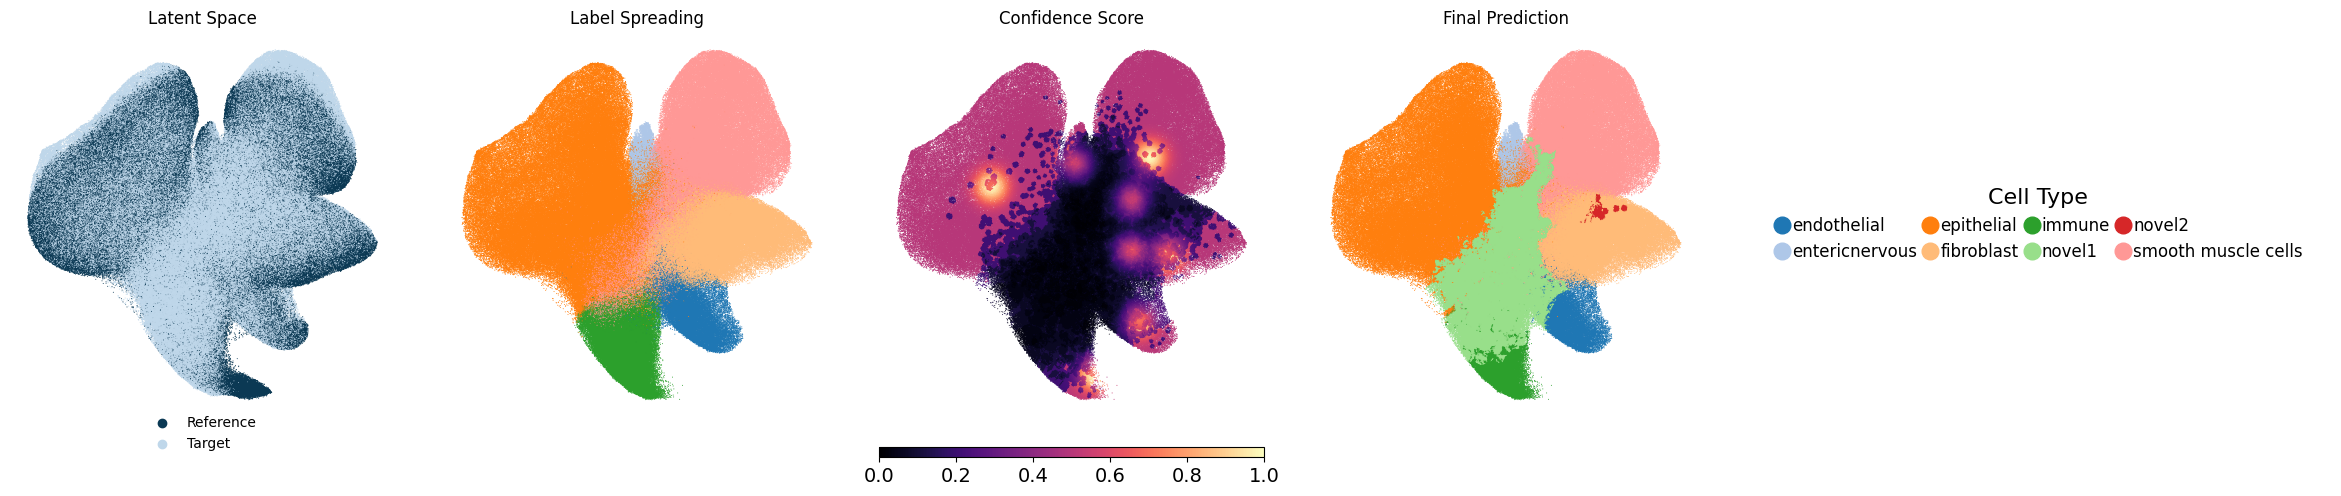

UMAP plot saved.
Generating spatial plot...


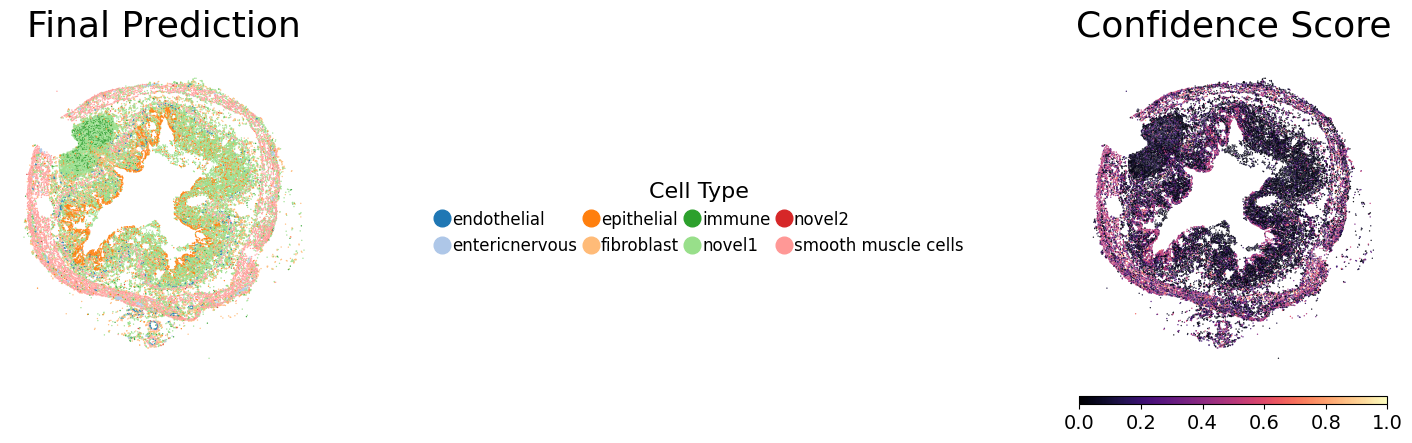

Spatial plot saved.

──────────────────────────────────────────
All seeds plotted successfully.



In [ ]:
NovAST_plot(args)